In [1]:
import re, math
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
report_path = Path("finalAnalysisReport_local.txt")  
text = report_path.read_text(errors="ignore")

In [4]:
# Linhas do NIST: 10 bins + p-value + (opcional '*') + num/den + (opcional '*') + testname
line_re = re.compile(
    r"""^
    \s*(?:\d+\s+){10}                 # C1..C10
    (?P<pval>[0-9]*\.[0-9]+)          # p-value (formato do NIST)
    (?:\s+\*)?                        # opcional '*' após p-value
    \s+(?P<pass_num>\d+)\s*/\s*(?P<pass_den>\d+)  # proporção num/den
    \s+(?:\*\s+)?                     # opcional '*' antes do nome do teste
    (?P<test>.+?)\s*$                 # nome do teste
    """,
    re.MULTILINE | re.VERBOSE
)

rows = []
for m in line_re.finditer(text):
    pval = float(m.group("pval"))
    num = int(m.group("pass_num"))
    den = int(m.group("pass_den"))
    test = m.group("test").strip()
    # Normaliza: remove '*' residuais, comprime espaços
    test = re.sub(r"\s+", " ", test.replace("*", "")).strip()
    rows.append((test, pval, num, den))

if not rows:
    raise ValueError("Não encontrei linhas de resultados. Verifique o formato do arquivo.")

df = pd.DataFrame(rows, columns=["test", "p_value", "pass_num", "pass_den"])
df["proportion"] = df["pass_num"] / df["pass_den"]

In [5]:
# Agregação por tipo de teste ===
# Escolha: "worst" (conservador) ou "mean" (médio)
AGG_MODE = "worst"  # ou "mean"

if AGG_MODE == "worst":
    agg = (df.groupby("test", as_index=False)
             .agg(p_value=("p_value", "min"),
                  proportion=("proportion", "min"),
                  pass_den=("pass_den", "max"),
                  n_rows=("p_value", "size")))
elif AGG_MODE == "mean":
    agg = (df.groupby("test", as_index=False)
             .agg(p_value=("p_value", "mean"),
                  proportion=("proportion", "mean"),
                  pass_den=("pass_den", "max"),
                  n_rows=("p_value", "size")))
else:
    raise ValueError("AGG_MODE deve ser 'worst' ou 'mean'")

# Ordem
order = [
    "Frequency","BlockFrequency","CumulativeSums","Runs","LongestRun","Rank","FFT",
    "NonOverlappingTemplate","OverlappingTemplate","Universal","ApproximateEntropy",
    "RandomExcursions","RandomExcursionsVariant","Serial","LinearComplexity"
]
present = [t for t in order if (agg["test"] == t).any()]
extras = [t for t in agg["test"].tolist() if t not in present]
plot_order = present + extras
agg["order"] = agg["test"].apply(lambda x: plot_order.index(x))
agg = agg.sort_values("order").reset_index(drop=True)

# Limiar do NIST para proporção ===
alpha = 0.01
p_hat = 1 - alpha

# limiar por denominador m
def min_pass_rate_for_m(m: int) -> float:
    return p_hat - 3 * math.sqrt(p_hat * (1 - p_hat) / m)

agg["min_pass_rate"] = agg["pass_den"].apply(lambda m: min_pass_rate_for_m(int(m)))


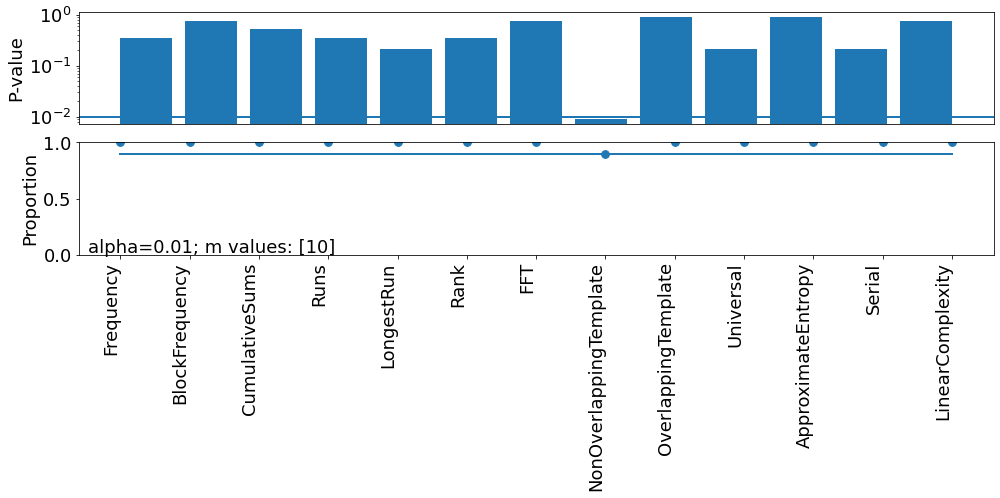

In [6]:
# === ) Plot (2 painéis) ===
plt.figure(figsize=(14, 7))

# Topo: P-values (log)
ax1 = plt.subplot(2, 1, 1)
ax1.bar(range(len(agg)), agg["p_value"])
ax1.set_yscale("log")
ax1.set_ylabel("P-value",fontsize=18)
ax1.axhline(alpha, linewidth=2)  # linha de significância
ax1.set_xticks([])
ax1.tick_params(axis="y", labelsize=18)
# ax1.set_title(
#     f"NIST SP 800-22 Summary — {report_path.name} (agg={AGG_MODE})\n"
#     f"alpha={alpha}, main m={m_main}"
# )



# Base: proporção
ax2 = plt.subplot(2, 1, 2)
x = range(len(agg))
ax2.scatter(x, agg["proportion"], s=60)

# referência por ponto (m pode variar)
ax2.plot(x, agg["min_pass_rate"], linewidth=2)

ax2.set_ylabel("Proportion", fontsize=18)
ax2.set_ylim(0.0, 1.001)  # ajuste conforme preferir
ax2.set_xticks(list(x))
ax2.set_xticklabels(agg["test"], rotation=90, ha="right")
ax2.tick_params(axis="y", labelsize=18)
ax2.tick_params(axis="x", labelsize=18)

# texto informativo: mostra os m distintos
ms = sorted(set(agg["pass_den"].astype(int).tolist()))
ax2.text(
    0.01, 0.02,
    f"alpha={alpha}; m values: {ms}",
    fontsize=18,
    transform=ax2.transAxes
)

plt.tight_layout()
plt.savefig(f"{report_path.name[:-4]}.pdf", format="pdf")
plt.show()